<a id = '5.5'></a>
<p style = "font-size : 25px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>Flight Price Prediction</strong></p>

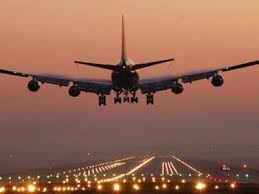

In [2]:
#importing libraries
import pandas as pd 
# 中文注释：导入pandas库，用于数据处理和操作，特别是对于DataFrame结构的操作。
import numpy as np 
# 中文注释：导入numpy库，主要用于数值计算和处理，如数组操作和线性代数运算。
import seaborn as sns 
# 中文注释：导入seaborn库，基于matplotlib的高级可视化库，用于创建统计图形，如箱型图、分布图等。
import matplotlib.pyplot as plt
# 中文注释：导入matplotlib库中的pyplot模块，主要用于绘制各类图表，如折线图、散点图等。
from sklearn.preprocessing import StandardScaler
# 中文注释：从sklearn.preprocessing模块导入StandardScaler类，用于特征标准化，通常用于将数据转换为均值为0，标准差为1的标准正态分布。
from sklearn.model_selection import train_test_split, GridSearchCV
# 中文注释：从sklearn.model_selection模块导入train_test_split函数，用于将数据集分为训练集和测试集；导入GridSearchCV类，用于模型超参数的网格搜索与交叉验证。
from sklearn.metrics import accuracy_score, confusion_matrix
# 中文注释：从sklearn.metrics模块导入accuracy_score和confusion_matrix函数，分别用于计算分类模型的准确率和混淆矩阵，评估模型性能。
import warnings
# 中文注释：导入warnings模块，用于处理Python中的警告信息。
warnings.filterwarnings('ignore')
# 中文注释：通过filterwarnings('ignore')函数，忽略所有警告信息，避免输出冗长的警告提示。

# Importing dataset
1.Since data is in form of excel file we have to use pandas read_excel to load the data.   
2.After loading it is important to check null values in a column or a row           
3.If it is present then following can be done,                                                                                   
*       Filling NaN values with mean, median and mode using fillna() method                                                           
*       If Less missing values, we can drop it as well         

1 导入数据集

1.由于数据是 excel 文件形式的，我们必须使用 pandas read_excel 来加载数据。

2.加载后，重要的是检查列或行中的空值。

3.如果存在空值，则可以执行以下操作、

使用 fillna() 方法用平均值、中位数和模式填补空值
如果缺失值较少，我们也可以将其删除

安装openpyxl，以便pandas能够读取Excel文件。

In [3]:
pip install openpyxl

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [6]:
#importing data
df=pd.read_excel('Data_Train.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
df.info()   #information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


Airline、Date_of_Journey、Source、Destination、Dep_Time、Arrival_Time、Duration、Additional_Info、Price 列都有10683个非空值，表示这些列没有缺失值。

Route和Total_Stops 列有10682个非空值，说明这两列有1个缺失值。

Price 列是整数类型（int64），其他列是对象类型（object），通常用于表示字符串数据。

In [9]:
#describe about the data
# `df.describe()`是Pandas库中的一个方法，用于对DataFrame中的数值列进行描述性统计分析。
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [10]:
df.shape

(10683, 11)

In [11]:
#finding the null values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

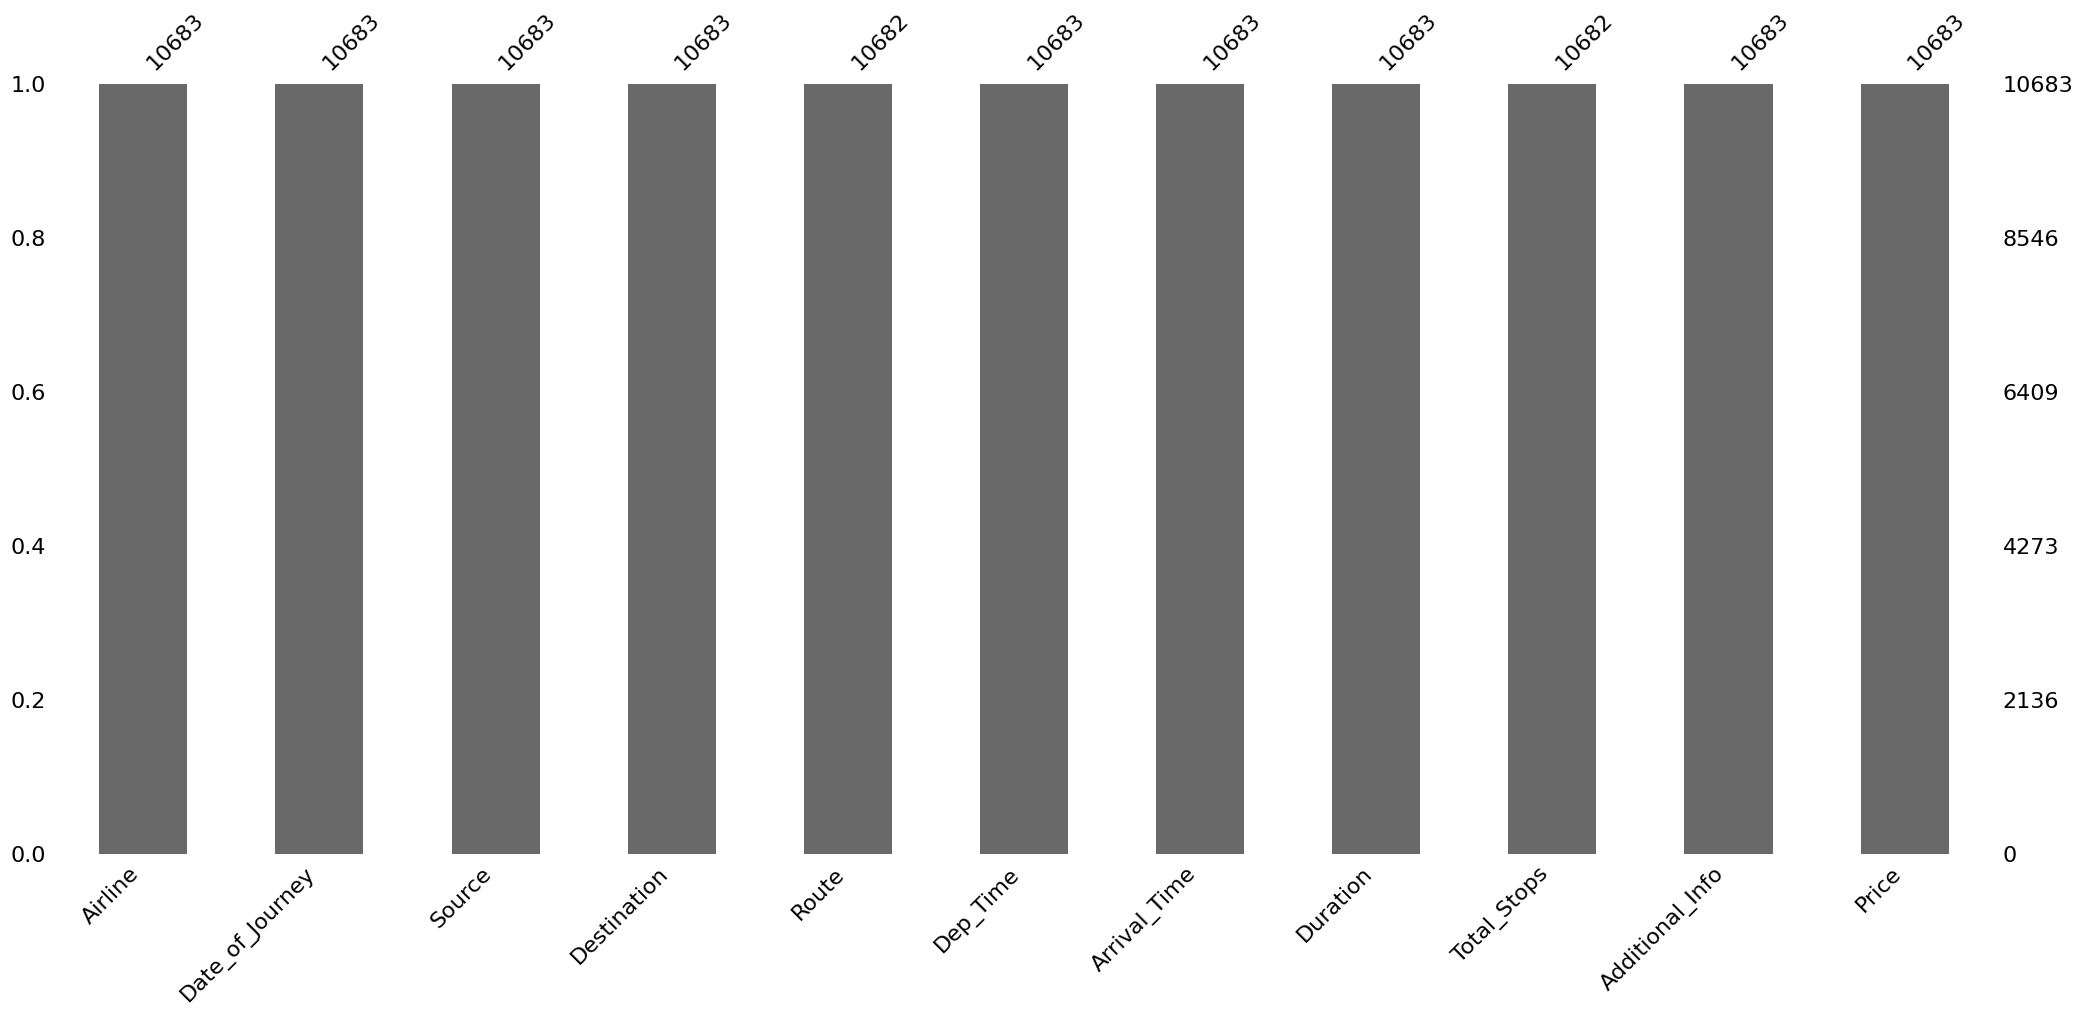

In [14]:
import missingno as msno
# 中文注释：
# 导入missingno库并给它取别名msno，missingno是一个Python可视化工具库，专门用于展示数据中的缺失值模式。

msno.bar(df)
# 中文注释：
# 使用missingno的`bar`函数绘制一个缺失值条形图。该图显示了每一列的缺失值数量，条形的长度代表每列中缺失值的数量，
# 通过这个图可以快速识别哪些列有缺失数据，哪些列数据完整。

plt.show()
# 中文注释：
# 使用`plt.show()`来显示绘制的图形。`plt.show()`是matplotlib中的方法，用于将绘制的图表显示出来。
# 注意：`plt.show()`后缺少圆括号`()`，需要补全才能正确显示图形：`plt.show()`


### **We observe 2 missing values,I can directly drop these,as these are very less.**
我们观察到 2 个缺失值，我可以直接放弃，因为这些缺失值非常少。

In [16]:
#drop the nullvalues
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

<a id = '5.5'></a>
<p style = "font-size : 25px; color : 'blue' ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>Data Cleaning</strong></p>

In [18]:
df.dtypes # datatypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

#### The datatypes of Date_of_journey,Arrival_Time and Dep_Time is object.So,firstly we convert it into date and time for proper predicion.

**dt.day method will extract only day of that date                           
dt.month method will extract only month of that date**

Date_of_journey、Arrival_Time 和 Dep_Time 的数据类型是对象。因此，我们首先将其转换为日期和时间，以便进行适当的预测。

dt.day 方法将只提取该日期的日

dt.month 方法将只提取该日期的月份。

In [19]:
def change_into_datetime(col):
    df[col]=pd.to_datetime(df[col])

In [20]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [21]:
for i in ['Date_of_Journey','Dep_Time', 'Arrival_Time']:
    change_into_datetime(i)

In [22]:
df.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

##### Now ,we extract day and month from Date_of_journey and stored in 2 other columns.
##### Then there will be no use of 'Date_of_Journey' column,so we drop it.
现在，我们从 “Date_of_journey ”中提取日期和月份，并存储在另外两列中。

这样一来，“Date_of_Journey ”列就没有用处了，因此我们将其删除。

In [23]:
df['journey_day']=df['Date_of_Journey'].dt.day
df['journey_month']=df['Date_of_Journey'].dt.month


In [24]:
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2024-12-11 22:20:00,2024-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2024-12-11 05:50:00,2024-12-11 13:15:00,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2024-12-11 09:25:00,2024-06-10 04:25:00,19h,2 stops,No info,13882,9,6
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2024-12-11 18:05:00,2024-12-11 23:30:00,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2024-12-11 16:50:00,2024-12-11 21:35:00,4h 45m,1 stop,No info,13302,1,3
5,SpiceJet,2019-06-24,Kolkata,Banglore,CCU → BLR,2024-12-11 09:00:00,2024-12-11 11:25:00,2h 25m,non-stop,No info,3873,24,6
6,Jet Airways,2019-03-12,Banglore,New Delhi,BLR → BOM → DEL,2024-12-11 18:55:00,2024-03-13 10:25:00,15h 30m,1 stop,In-flight meal not included,11087,12,3
7,Jet Airways,2019-03-01,Banglore,New Delhi,BLR → BOM → DEL,2024-12-11 08:00:00,2024-03-02 05:05:00,21h 5m,1 stop,No info,22270,1,3
8,Jet Airways,2019-03-12,Banglore,New Delhi,BLR → BOM → DEL,2024-12-11 08:55:00,2024-03-13 10:25:00,25h 30m,1 stop,In-flight meal not included,11087,12,3
9,Multiple carriers,2019-05-27,Delhi,Cochin,DEL → BOM → COK,2024-12-11 11:25:00,2024-12-11 19:15:00,7h 50m,1 stop,No info,8625,27,5


In [25]:
df.drop('Date_of_Journey', axis=1, inplace=True)

##### From Arrival_time and Dept_time features,we extract hour and minutes and stored in new columns and drop these columns

从 Arrival_time 和 Dept_time 特征中，我们提取出小时和分钟，并存储在新列中，然后删除这些列

In [26]:
# function for extracting hour and minutes
def extract_hour(data,col):
    data[col+'_hour']=data[col].dt.hour
    
def extract_min(data,col):
    data[col+'_min']=data[col].dt.minute
    

def drop_col(data,col):
    data.drop(col,axis=1,inplace=True)

In [27]:
#call the function
# Departure time is when a plane leaves the gate. 
# Similar to Date_of_Journey we can extract values from Dep_Time
extract_hour(df,'Dep_Time')

#extracting minutes
extract_min(df,'Dep_Time')

#drop the column
drop_col(df,'Dep_Time')

In [28]:
#extracting hour
extract_hour(df,'Arrival_Time')

#extracting min
extract_min(df,'Arrival_Time')


#drop the column
drop_col(df,'Arrival_Time')

In [29]:
df.head(10)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,Dep_Time_hour,Dep_Time_min,Arrival_Time_hour,Arrival_Time_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35
5,SpiceJet,Kolkata,Banglore,CCU → BLR,2h 25m,non-stop,No info,3873,24,6,9,0,11,25
6,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,15h 30m,1 stop,In-flight meal not included,11087,12,3,18,55,10,25
7,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,21h 5m,1 stop,No info,22270,1,3,8,0,5,5
8,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,25h 30m,1 stop,In-flight meal not included,11087,12,3,8,55,10,25
9,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,7h 50m,1 stop,No info,8625,27,5,11,25,19,15


##### Lets Apply pre-processing on duration column,Separate Duration hours and minute from duration

让我们对持续时间列进行预处理，从持续时间中分离出小时和分钟。

In [30]:
duration=list(df['Duration'])
for i in range(len(duration)):
    if len(duration[i].split(' '))==2:
        pass
    else:
        if 'h' in duration[i]: # Check if duration contains only hour
             duration[i]=duration[i] + ' 0m' # Adds 0 minute
        else:
             duration[i]='0h '+ duration[i]

In [31]:
df['Duration']=duration

In [32]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,Dep_Time_hour,Dep_Time_min,Arrival_Time_hour,Arrival_Time_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [33]:
# `hour`函数用于从一个表示持续时间的字符串（例如："2h 30m"）中提取小时部分
def hour(x):
    return x.split(' ')[0][0:-1]

# `minutes`函数用于从一个表示持续时间的字符串（例如："2h 30m"）中提取分钟部分
def minutes(x):
    return x.split(' ')[1][0:-1]



In [34]:
df['dur_hour']=df['Duration'].apply(hour)

In [35]:
df['dur_min']=df['Duration'].apply(minutes)

In [37]:
df.head(10)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,Dep_Time_hour,Dep_Time_min,Arrival_Time_hour,Arrival_Time_min,dur_hour,dur_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,4,45
5,SpiceJet,Kolkata,Banglore,CCU → BLR,2h 25m,non-stop,No info,3873,24,6,9,0,11,25,2,25
6,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,15h 30m,1 stop,In-flight meal not included,11087,12,3,18,55,10,25,15,30
7,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,21h 5m,1 stop,No info,22270,1,3,8,0,5,5,21,5
8,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,25h 30m,1 stop,In-flight meal not included,11087,12,3,8,55,10,25,25,30
9,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,7h 50m,1 stop,No info,8625,27,5,11,25,19,15,7,50


In [38]:
drop_col(df,'Duration')

In [39]:
df.dtypes

Airline              object
Source               object
Destination          object
Route                object
Total_Stops          object
Additional_Info      object
Price                 int64
journey_day           int32
journey_month         int32
Dep_Time_hour         int32
Dep_Time_min          int32
Arrival_Time_hour     int32
Arrival_Time_min      int32
dur_hour             object
dur_min              object
dtype: object

In [40]:
df['dur_hour'] = df['dur_hour'].astype(int)
df['dur_min'] = df['dur_min'].astype(int)

In [41]:
df.dtypes

Airline              object
Source               object
Destination          object
Route                object
Total_Stops          object
Additional_Info      object
Price                 int64
journey_day           int32
journey_month         int32
Dep_Time_hour         int32
Dep_Time_min          int32
Arrival_Time_hour     int32
Arrival_Time_min      int32
dur_hour              int64
dur_min               int64
dtype: object

#### Finding the categorical value
查找分类值

In [42]:
column=[column for column in df.columns if df[column].dtype=='object']
column

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

#### Finding the cntinuous value
查找连续值

In [43]:
continuous_col =[column for column in df.columns if df[column].dtype!='object']
continuous_col

['Price',
 'journey_day',
 'journey_month',
 'Dep_Time_hour',
 'Dep_Time_min',
 'Arrival_Time_hour',
 'Arrival_Time_min',
 'dur_hour',
 'dur_min']

# Handling categorical data
处理分类数据


### We are using two main Encoding Techniques to covert Categorical data into some numerical format

#### Nominal data -- Data that are not in any order -->one hot encoding
#### ordinal data -- Data are in order --> labelEncoder
我们使用两种主要的编码技术，将分类数据转换为数值格式

名义数据——没有顺序关系的数据 → 独热编码（One Hot Encoding）

序数数据——具有顺序关系的数据 → 标签编码（Label Encoding）


In [44]:
categorical = df[column]

In [45]:
categorical.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info


In [46]:
categorical['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

## Airline vs Price Analysis
航空公司与价格分析

<Axes: xlabel='Airline', ylabel='Price'>

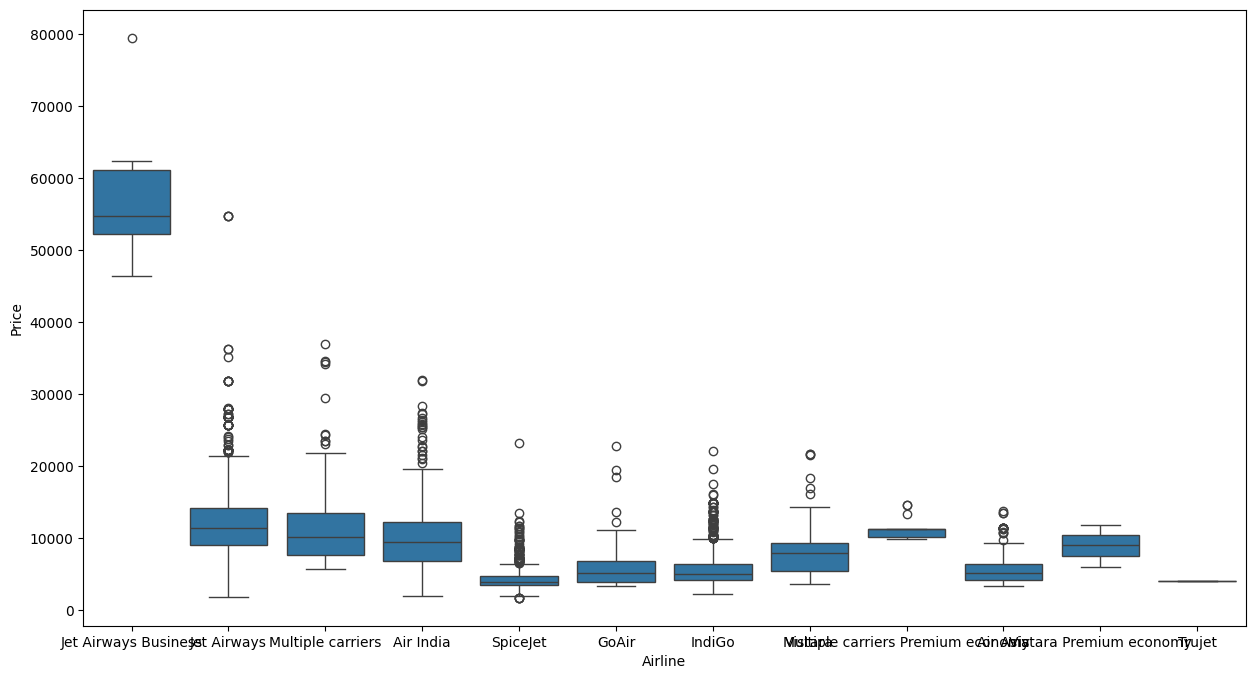

In [56]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Airline', y='Price', data=df.sort_values('Price', ascending=False))
# 中文注释：
# `sns.boxplot()` 是seaborn库中的箱型图函数，用于绘制箱型图，通常用于展示数据的分布情况，包括中位数、四分位数、最大值、最小值及异常值。
# - `x='Airline'`：指定x轴为`Airline`列，表示不同的航空公司。
# - `y='Price'`：指定y轴为`Price`列，表示票价。
# - `data=df.sort_values('Price', ascending=False)`：使用数据框`df`，并按`Price`列对数据进行降序排列，以便显示较高票价的航空公司在前面。


### From graph we can see that Jet Airways Business have the highest Price., Apart from the first Airline almost all are having similar median
从图中可以看出，Jet Airways Business商务舱的价格最高。

#### Perform Total_Stops vs Price Analysis
Total_Stops与价格分析

<Axes: xlabel='Total_Stops', ylabel='Price'>

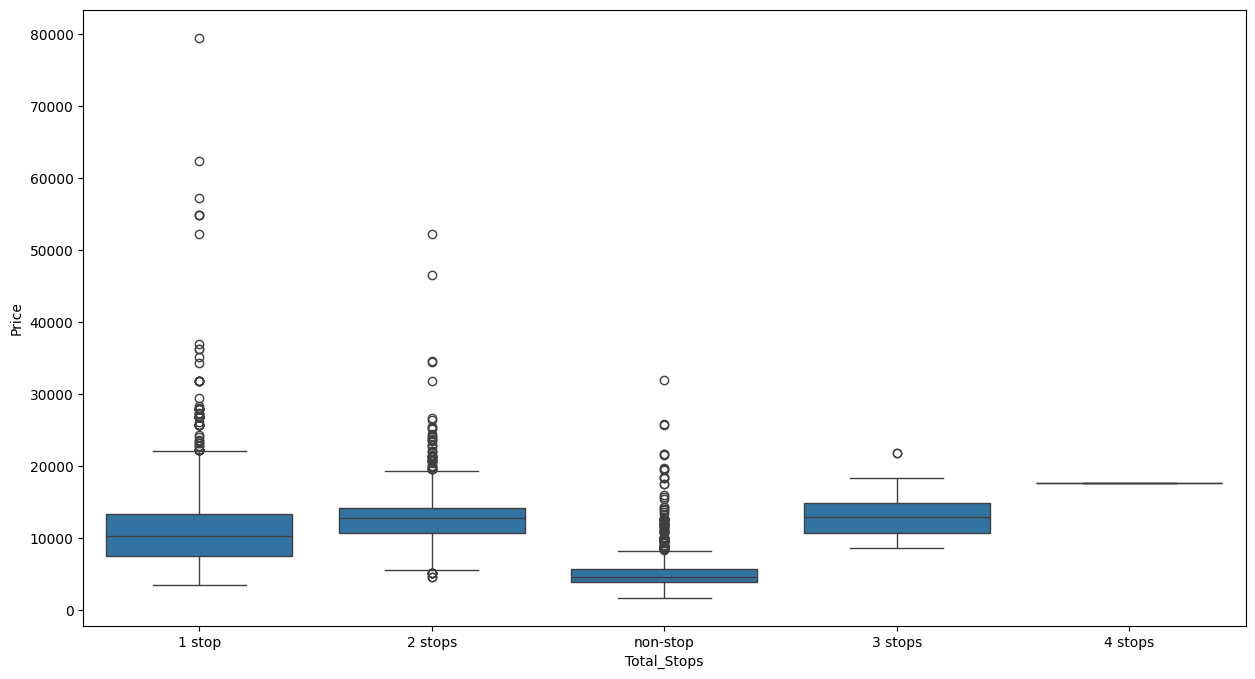

In [57]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Total_Stops',y='Price',data=df.sort_values('Price',ascending=False))

In [58]:
# 因为 `Airline` 是无序分类数据（Nominal Categorical Data），所以我们对其进行独热编码（One-Hot Encoding）。
# 独热编码将每个类别转换为二进制向量，这样可以避免将分类数据直接转化为数字引入的错误顺序关系。

Airline = pd.get_dummies(categorical['Airline'], drop_first=True)
# 中文注释：
# 使用 Pandas 的 `get_dummies()` 方法对 `Airline` 列进行独热编码。
# - `categorical['Airline']`：指定需要编码的列（这里是 `Airline` 列）。
# - `drop_first=True`：删除第一个类别的列以避免虚拟变量陷阱（Dummy Variable Trap）。

In [59]:
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [60]:
categorical['Source'].value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

<Figure size 1500x1500 with 0 Axes>

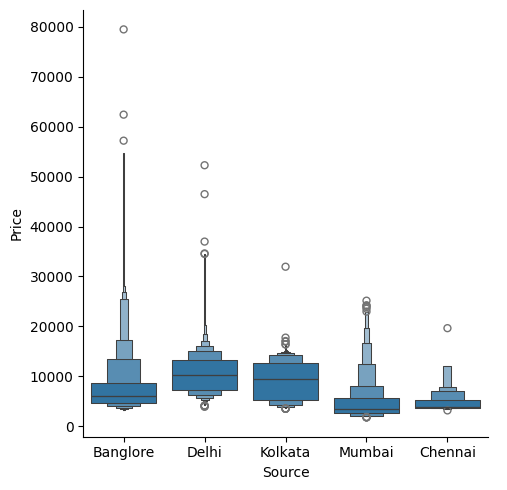

In [62]:
# 本段代码的目的是对 `Source` 列（航班出发地）与 `Price` 列（票价）之间的关系进行可视化分析。
# 它使用的是 `seaborn` 中的分类绘图函数 `catplot`，并通过 `boxen` 图展示票价分布情况。

plt.figure(figsize=(15,15))
# 中文注释：
# 使用 `plt.figure(figsize=(15,15))` 设置图形的尺寸，宽度和高度均为 15 英寸。
# 这是为了确保图表能够容纳所有类别并且清晰易读。

sns.catplot(x='Source', y='Price', data=df.sort_values('Price', ascending=False), kind='boxen')

In [63]:
#encoding of source column
source=pd.get_dummies(categorical['Source'],drop_first=True)
source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [64]:
categorical['Destination'].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

<Axes: xlabel='Destination', ylabel='Price'>

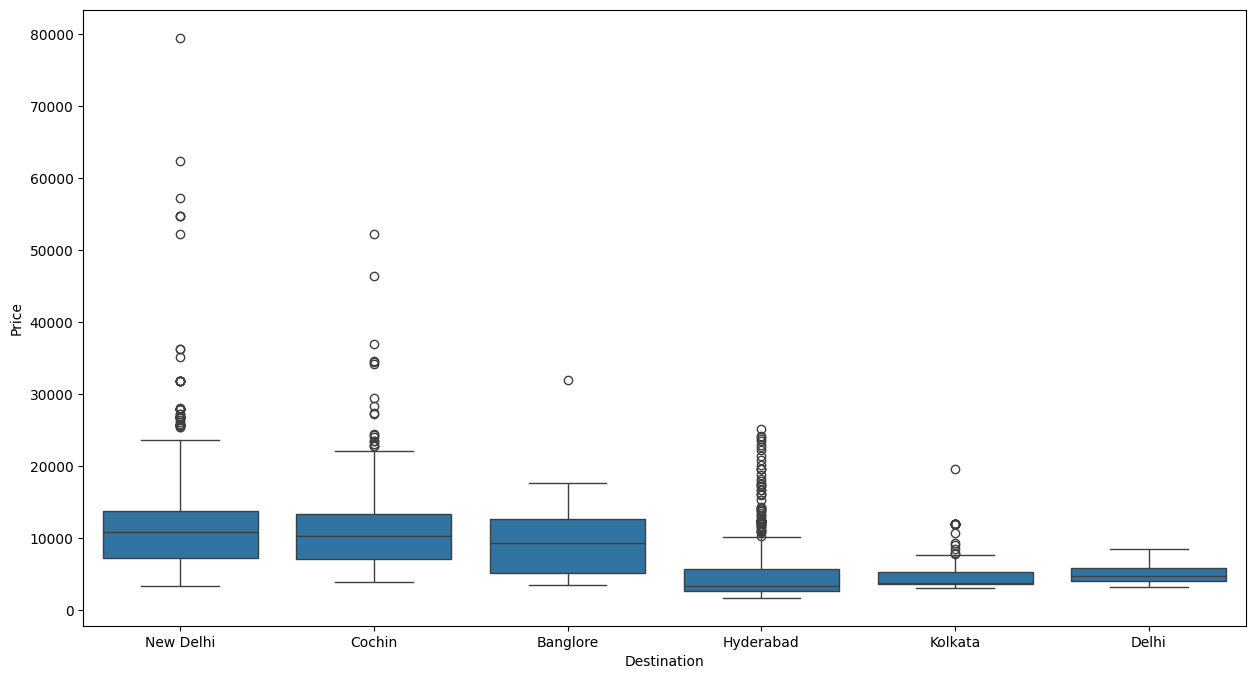

In [65]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Destination',y='Price',data=df.sort_values('Price',ascending=False))

In [66]:
#encoding of destination column
destination=pd.get_dummies(categorical['Destination'],drop_first=True)
destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [67]:
# now work on route column
categorical['Route'].value_counts()

Route
DEL → BOM → COK          2376
BLR → DEL                1552
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → CCU → HYD             1
BOM → BBI → HYD             1
Name: count, Length: 128, dtype: int64

In [68]:
categorical['Route1']=categorical['Route'].str.split('→').str[0]
categorical['Route2']=categorical['Route'].str.split('→').str[1]
categorical['Route3']=categorical['Route'].str.split('→').str[2]
categorical['Route4']=categorical['Route'].str.split('→').str[3]
categorical['Route5']=categorical['Route'].str.split('→').str[4]

In [69]:
categorical.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Route1,Route2,Route3,Route4,Route5
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,BLR,DEL,NaN,NaN,NaN
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,CCU,IXR,BBI,BLR,NaN
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,DEL,LKO,BOM,COK,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,CCU,NAG,BLR,NaN,NaN
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,BLR,NAG,DEL,NaN,NaN


In [70]:
drop_col(categorical,'Route')

In [71]:
categorical.isnull().sum()

Airline                0
Source                 0
Destination            0
Total_Stops            0
Additional_Info        0
Route1                 0
Route2                 0
Route3              3491
Route4              9116
Route5             10636
dtype: int64

In [72]:
categorical.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Route1', 'Route2', 'Route3', 'Route4', 'Route5'],
      dtype='object')

In [73]:
for i in ['Route3', 'Route4', 'Route5']:
    categorical[i].fillna('None',inplace=True)

In [75]:
categorical.isnull().sum()

Airline            0
Source             0
Destination        0
Total_Stops        0
Additional_Info    0
Route1             0
Route2             0
Route3             0
Route4             0
Route5             0
dtype: int64

In [76]:
for i in categorical.columns:
    print('{} has total {} categories'.format(i,len(categorical[i].value_counts())))

Airline has total 12 categories
Source has total 5 categories
Destination has total 6 categories
Total_Stops has total 5 categories
Additional_Info has total 10 categories
Route1 has total 5 categories
Route2 has total 45 categories
Route3 has total 30 categories
Route4 has total 14 categories
Route5 has total 6 categories


<Axes: xlabel='Arrival_Time_hour', ylabel='Price'>

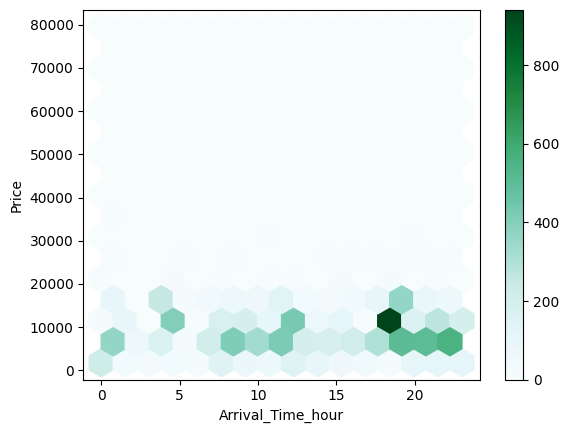

In [77]:
df.plot.hexbin(x='Arrival_Time_hour', y='Price', gridsize=15)
# 中文注释：
# 这段代码使用 Pandas 提供的 `hexbin`（六边形分箱图）绘制图表，目的是分析 `Arrival_Time_hour`（到达时间小时）与 `Price`（票价）之间的关系。
# 六边形分箱图将数据点按密度分布显示，以便观察两个变量之间的相关性或分布特性。

# 参数说明：
# - `x='Arrival_Time_hour'`：指定横轴为 `Arrival_Time_hour` 列，表示航班的到达时间（小时）。
# - `y='Price'`：指定纵轴为 `Price` 列，表示票价。
# - `gridsize=15`：指定六边形网格的大小，值越大，网格越小；值越小，网格越大。这里设置为 15。

In [78]:
# Applying label encoder
# 中文注释：
# 开始应用标签编码（Label Encoding），用于将分类数据转换为数值格式。

from sklearn.preprocessing import LabelEncoder
# 中文注释：
# 从 scikit-learn 库中导入 `LabelEncoder` 类，这是一个简单的编码器，专门用于将分类数据中的类别标签转换为整数值。

encoder = LabelEncoder()
# 中文注释：
# 创建一个 `LabelEncoder` 对象实例，命名为 `encoder`。
# 该对象将用于对分类数据进行编码，将类别（例如字符串或文本数据）映射为唯一的整数值。

In [79]:
for i in ['Route1', 'Route2', 'Route3', 'Route4', 'Route5']:
    categorical[i]=encoder.fit_transform(categorical[i])

In [80]:
categorical.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Route1,Route2,Route3,Route4,Route5
0,IndiGo,Banglore,New Delhi,non-stop,No info,0,13,29,13,5
1,Air India,Kolkata,Banglore,2 stops,No info,2,25,1,3,5
2,Jet Airways,Delhi,Cochin,2 stops,No info,3,32,4,5,5
3,IndiGo,Kolkata,Banglore,1 stop,No info,2,34,3,13,5
4,IndiGo,Banglore,New Delhi,1 stop,No info,0,34,8,13,5


In [81]:
drop_col(categorical,'Additional_Info')

In [82]:
categorical['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [83]:
# encoding Total stops
dict={'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}
categorical['Total_Stops']=categorical['Total_Stops'].map(dict)

In [84]:
categorical['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

In [85]:
drop_col(categorical,'Source')
drop_col(categorical,'Destination')
drop_col(categorical,'Airline')

In [86]:
categorical.head()

,Total_Stops,Route1,Route2,Route3,Route4,Route5
0,0,0,13,29,13,5
1,2,2,25,1,3,5
2,2,3,32,4,5,5
3,1,2,34,3,13,5
4,1,0,34,8,13,5


<a id = '5.5'></a>
<p style = "font-size : 25px; color : #34656d ; font-family : 'Comic Sans MS'; text-align : center; background-color : #fbc6a4; border-radius: 5px 5px;"><strong>After all preprocessing, Our data is ready for the modeling</strong></p> 

In [87]:
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [88]:
source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [89]:
destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [90]:
final_df=pd.concat([categorical,Airline,source,destination,df[continuous_col]],axis=1)

In [91]:
final_df.head()

,Total_Stops,Route1,Route2,Route3,Route4,Route5,Air India,GoAir,IndiGo,Jet Airways,...,New Delhi,Price,journey_day,journey_month,Dep_Time_hour,Dep_Time_min,Arrival_Time_hour,Arrival_Time_min,dur_hour,dur_min
0,0,0,13,29,13,5,False,False,True,False,...,True,3897,24,3,22,20,1,10,2,50
1,2,2,25,1,3,5,True,False,False,False,...,False,7662,1,5,5,50,13,15,7,25
2,2,3,32,4,5,5,False,False,False,True,...,False,13882,9,6,9,25,4,25,19,0
3,1,2,34,3,13,5,False,False,True,False,...,False,6218,12,5,18,5,23,30,5,25
4,1,0,34,8,13,5,False,False,True,False,...,True,13302,1,3,16,50,21,35,4,45


In [92]:
pd.set_option('display.max_columns', 33)
# 中文注释：
# 使用 Pandas 的 `set_option` 方法设置显示选项。
# 参数 `display.max_columns` 用于指定在输出表格中最多显示的列数。
# 这里设置为 33，表示在使用 Pandas 的 `print` 或 `head()` 等方法显示数据框时，最多显示 33 列。
# 如果数据框的列数超过 33，则会被截断或以省略号的形式显示多余列。

final_df.head()
# 中文注释：
# 调用 `final_df.head()` 方法显示数据框 `final_df` 的前 5 行数据。
# `head()` 是 Pandas 中的一个方法，用于快速查看数据框的前几行（默认为 5 行），方便检查数据的内容和结构。

,Total_Stops,Route1,Route2,Route3,Route4,Route5,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,...,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Price,journey_day,journey_month,Dep_Time_hour,Dep_Time_min,Arrival_Time_hour,Arrival_Time_min,dur_hour,dur_min
0,0,0,13,29,13,5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,3897,24,3,22,20,1,10,2,50
1,2,2,25,1,3,5,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,7662,1,5,5,50,13,15,7,25
2,2,3,32,4,5,5,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,13882,9,6,9,25,4,25,19,0
3,1,2,34,3,13,5,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,6218,12,5,18,5,23,30,5,25
4,1,0,34,8,13,5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,13302,1,3,16,50,21,35,4,45


## Check For Outliers 
检查异常值

In [93]:
def plot(data, col):
    # 定义一个名为 `plot` 的函数，用于对数据中的某一列进行分布和箱型图的可视化分析。
    fig, (ax1, ax2) = plt.subplots(2, 1)
    # 使用 Matplotlib 的 `plt.subplots()` 创建一个包含两个子图（ax1 和 ax2）的图形。
    # 参数 `(2, 1)` 指定有 2 行 1 列的布局，即一个图形上下排列两个子图。
    # - `fig` 是整个图形对象。
    # - `ax1` 和 `ax2` 是两个子图的轴对象。
    sns.distplot(data[col], ax=ax1)
    # 使用 Seaborn 的 `distplot()` 绘制指定列（`col`）的分布图。
    # 分布图结合了直方图和密度估计曲线，可以用来观察数据的分布情况（如正态分布、偏态分布等）。
    # - `data[col]`：需要绘制分布图的列。
    # - `ax=ax1`：将分布图绘制在第一个子图上。
    sns.boxplot(data[col], ax=ax2)
    # 使用 Seaborn 的 `boxplot()` 绘制指定列的箱型图。
    # 箱型图展示了数据的统计特性，包括中位数、四分位数、异常值等。
    # - `data[col]`：需要绘制箱型图的列。
    # - `ax=ax2`：将箱型图绘制在第二个子图上。

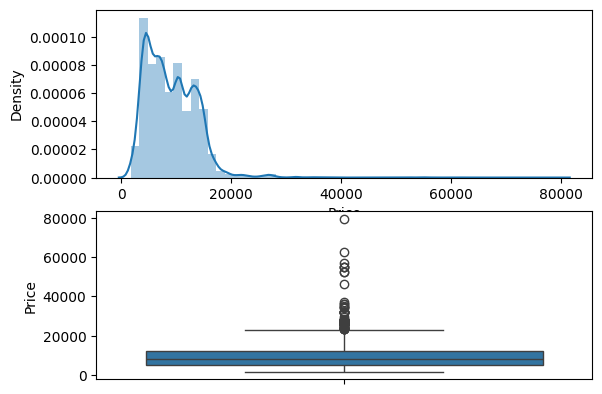

In [94]:
plot(final_df,'Price')

###  Handling outliers:
#### As there is some outliers in price feature,so we replace it  with median.

2.2.1 处理异常值：

2.2.1.1 由于价格特征中存在一些离群值，因此我们用中位数代替它。

In [95]:
final_df['Price']=np.where(final_df['Price']>=40000,final_df['Price'].median(),final_df['Price'])

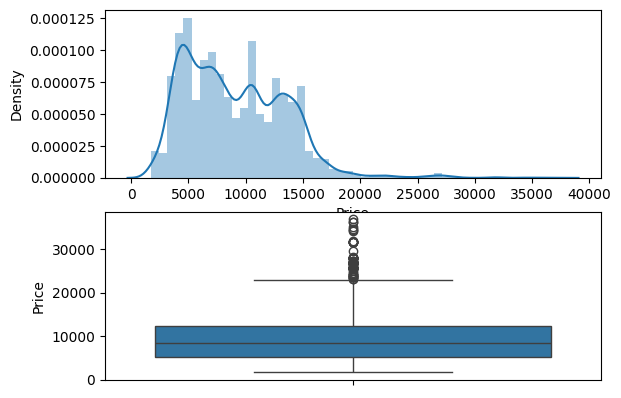

In [96]:
plot(final_df,'Price')

### Seprate the dataset in X and Y columns
将数据集分为 X 列和 Y 列

In [97]:
X=final_df.drop('Price',axis=1)
y=df['Price']

# Feature Selection 
It is about finding the best feature and having good relation with independent variable                                  
Issue of dimensionality reduction reduces.

For this we use mutual_info_classif

3 特征选择

特征选择是指找到与自变量有良好关系的最佳特征。
减少了降维问题。

为此，我们使用互信息分类法（mutual_info_classif

In [99]:
from sklearn.feature_selection import mutual_info_classif
# 从 `sklearn.feature_selection` 模块中导入 `mutual_info_classif` 函数。
# 该函数用于计算输入特征（特征列）与目标变量（分类标签）之间的互信息（Mutual Information）。
# 互信息是一种度量，表示两个变量之间的相关性，可以用来评估每个特征对目标变量的重要性。

In [100]:
mutual_info_classif(X, y)
# 调用 `mutual_info_classif` 函数，用于计算特征矩阵 `X` 中的每个特征与目标变量 `y` 之间的互信息（Mutual Information）。
# 结果是一个数组，包含每个特征与目标变量的互信息得分。

array([1.94540819e+00, 2.32815599e+00, 2.94544853e+00, 2.56538467e+00,
       1.71414367e+00, 1.39802753e+00, 6.94455990e-01, 7.21488305e-02,
       6.22634245e-01, 8.83720703e-01, 8.55527777e-03, 5.29020631e-01,
       0.00000000e+00, 2.97693805e-01, 1.21368097e-03, 2.22699084e-01,
       3.80391778e-03, 1.51275793e-01, 1.38540036e+00, 7.97540566e-01,
       2.76798931e-01, 1.40712888e+00, 4.02063663e-01, 2.80423008e-01,
       1.76903337e-01, 3.50209996e-01, 8.71806532e-01, 1.66505157e+00,
       1.53440435e+00, 1.30090554e+00, 1.91953131e+00, 1.64615352e+00,
       1.78314534e+00, 1.13920048e+00])

In [102]:
imp = pd.DataFrame(mutual_info_classif(X, y), index=X.columns)
# 调用 `mutual_info_classif(X, y)` 函数计算每个特征与目标变量 `y` 之间的互信息得分。
# `mutual_info_classif(X, y)` 返回一个包含每个特征与目标变量互信息得分的数组。
# 然后，使用 `pd.DataFrame` 将这个数组转换为一个 DataFrame 对象，并设置 `X.columns` 作为行索引。
# 这样可以清楚地将每个特征的互信息得分与特征名称对应起来，便于查看和分析。
imp
# 输出 `imp`，显示包含特征与目标变量互信息得分的数据框。
# 该数据框的行表示特征名称，列表示互信息得分。
# 例如，第一列是特征名称（`X.columns`），第二列是对应的互信息得分。

,0
Total_Stops,1.878250
Route1,2.295807
Route2,2.993255
Route3,2.602102
Route4,1.714182
Route5,1.424794
Air India,0.703539
GoAir,0.081740
IndiGo,0.621249
Jet Airways,0.897015


In [103]:
imp.columns=['importance']
imp.sort_values(by='importance',ascending=False)

,importance
Route2,2.993255
Route3,2.602102
Route1,2.295807
Arrival_Time_hour,1.897892
Total_Stops,1.878250
dur_hour,1.783499
Route4,1.714182
journey_month,1.642122
Arrival_Time_min,1.619828
Dep_Time_hour,1.520519


As we can see from the table, there are several features that have approx 0 value,so we should remove it after authorizing it.But for now,we are not removing it.

从表中可以看出，有几项功能的值约为 0，因此我们应该在授权后将其删除。

# Models

In [104]:
# 这段代码用于将数据集分割为训练集和测试集，以便在机器学习模型中进行训练和评估。

from sklearn.model_selection import train_test_split
# 从 `sklearn.model_selection` 模块导入 `train_test_split` 函数，这是一个用于分割数据集的工具。
# 它可以将数据集划分为训练集和测试集，用于训练和评估机器学习模型。

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123)
# 调用 `train_test_split` 函数，将特征矩阵 `X` 和目标变量 `y` 分割成训练集和测试集。
# - `X`：输入特征矩阵，包含所有特征。
# - `y`：目标变量，包含每个样本的标签或输出。
# - `test_size=0.20`：指定测试集的比例为 20%，即 80% 的数据用于训练，20% 用于测试。
# - `random_state=123`：设置随机种子，确保每次分割数据集时结果一致，便于复现实验。

In [105]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def predict(ml_model):
    print('Model is: {}'.format(ml_model))
    # 打印当前正在使用的机器学习模型的名称。
    # 通过 `format` 将 `ml_model` 插入到字符串中，输出模型的类型。

    model = ml_model.fit(X_train, y_train)
    # 使用 `fit` 方法将 `ml_model` 模型应用于训练数据 `X_train` 和 `y_train` 进行训练。
    # `fit` 方法会基于训练集数据对模型进行训练，并返回训练好的模型对象。

    print("Training score: {}".format(model.score(X_train, y_train)))
    # 使用 `model.score()` 方法计算并打印训练集上的模型得分（例如回归任务中的 R² 分数）。
    # 这是评估模型在训练集上的拟合程度。

    predictions = model.predict(X_test)
    # 使用训练好的模型对测试集 `X_test` 进行预测，并将预测结果存储在 `predictions` 变量中。

    print("Predictions are: {}".format(predictions))
    # 打印模型的预测结果 `predictions`，即测试集的预测值。

    print('\n')
    # 打印一个换行符，用于格式化输出。

    r2score = r2_score(y_test, predictions)
    # 使用 `r2_score` 函数计算 R² 得分，评估模型在测试集上的拟合优度。
    # R² 值越接近 1，说明模型越能解释目标变量的变化。

    print("r2 score is: {}".format(r2score))
    # 打印 R² 得分，表示模型对测试数据的拟合程度。

    print('MAE:{}'.format(mean_absolute_error(y_test, predictions)))
    # 使用 `mean_absolute_error` 计算并打印测试集上的平均绝对误差（MAE）。
    # MAE 表示预测值与实际值之间差距的平均值，值越小表示模型预测越准确。

    print('MSE:{}'.format(mean_squared_error(y_test, predictions)))
    # 使用 `mean_squared_error` 计算并打印测试集上的均方误差（MSE）。
    # MSE 表示预测值与实际值之间差距的平方的平均值，值越小表示模型预测越准确。

    print('RMSE:{}'.format(np.sqrt(mean_squared_error(y_test, predictions))))
    # 计算并打印根均方误差（RMSE），即 MSE 的平方根。
    # RMSE 与 MSE 类似，但它的单位与目标变量相同，通常用于度量预测误差。

    sns.distplot(y_test - predictions)
    # 使用 `seaborn.distplot()` 绘制预测误差的分布图，显示真实值与预测值的差异（残差）。
    # 通过残差分布图可以了解模型的误差是否呈现正态分布，帮助评估模型的预测效果。

In [106]:
from sklearn.linear_model import LogisticRegression
# 逻辑回归模型，主要用于二分类任务。尽管名字中带有“回归”，但通常用于分类任务，预测结果为类别标签（0 或 1）。

from sklearn.neighbors import KNeighborsRegressor
# K近邻回归模型。通过查找目标点周围 K 个最近邻的数据点，使用这些点的平均值来进行预测，适合非线性数据。

from sklearn.tree import DecisionTreeRegressor
# 决策树回归模型。使用树状结构进行预测，通过对特征空间进行划分来进行回归预测，易于理解但容易过拟合。

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
# 集成学习方法：
# - 梯度提升回归模型，通过逐步训练多个弱学习器（通常是决策树），将它们的预测结果组合，提高性能。
# - 随机森林回归模型，基于多个决策树的集成，具有较强的鲁棒性和准确性，通常比单一决策树更能避免过拟合。

Model is: RandomForestRegressor()
Training score: 0.9533324971536677
Predictions are: [ 8509.47166667 17317.44333333 14110.36333333 ...  3827.56
  5693.33       10525.273     ]


r2 score is: 0.8417525993555668
MAE:1086.0966929116353
MSE:3047160.9206218114
RMSE:1745.611904353832


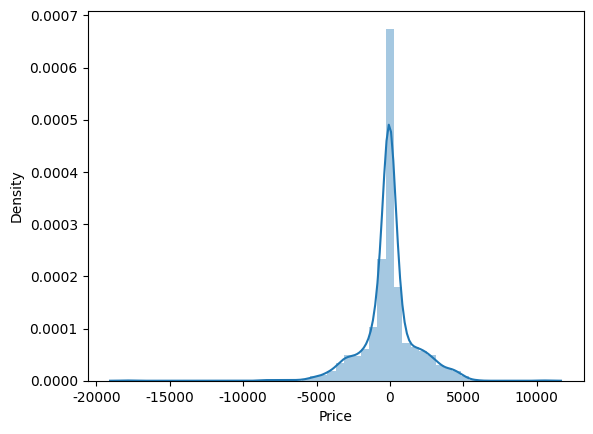

In [107]:
predict(RandomForestRegressor())

From the graph,it is clear that we predicted 84% correctly.

从图中可以看出，我们的预测正确率为 84%。

Model is: LogisticRegression()
Training score: 0.347571679344646
Predictions are: [14781 15237 10844 ...  4226  7888 10262]


r2 score is: 0.3930514772169186
MAE:1923.796443612541
MSE:11687205.046794571
RMSE:3418.6554442930587


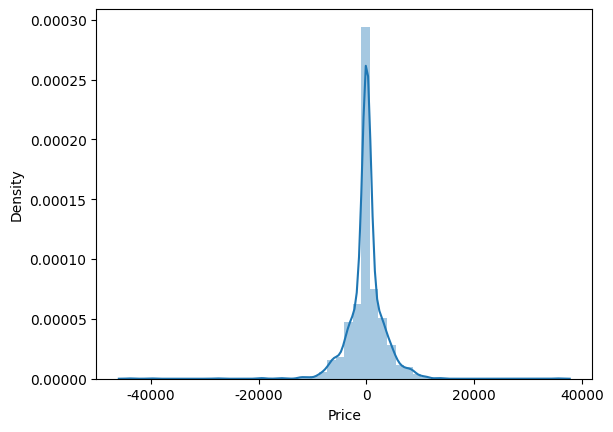

In [108]:
predict(LogisticRegression())

Model is: KNeighborsRegressor()
Training score: 0.746380546942052
Predictions are: [10401.2 16362.4 12933.2 ...  4210.   9073.  11232.4]


r2 score is: 0.6544658783016435
MAE:1700.4507253158633
MSE:6653493.631445953
RMSE:2579.436688784191


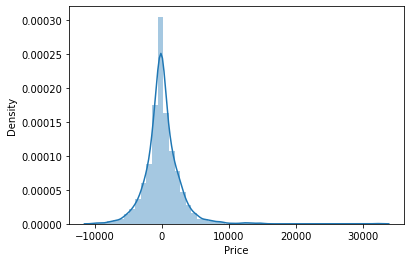

In [84]:
predict(KNeighborsRegressor())

Model is: DecisionTreeRegressor()
Training score: 0.9701124435927416
Predictions are: [ 8996. 17024. 14571. ...  3943.  5054. 10262.]


r2 score is: 0.7374996091123855
MAE:1254.5940570893777
MSE:5054622.884820361
RMSE:2248.2488485086255


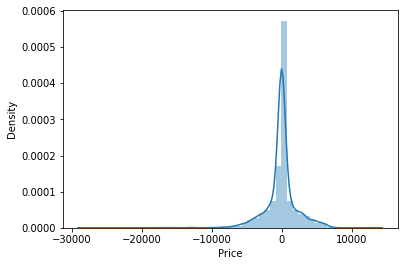

In [85]:
predict(DecisionTreeRegressor())

Model is: SVR()
Training score: 0.03692168715331767
Predictions are: [8516.40489669 8265.65249704 8451.37570001 ... 8298.82178087 8460.32416591
 8545.25725503]


r2 score is: 0.0527698349034188
MAE:3326.758076720636
MSE:18239558.628844902
RMSE:4270.779627754739


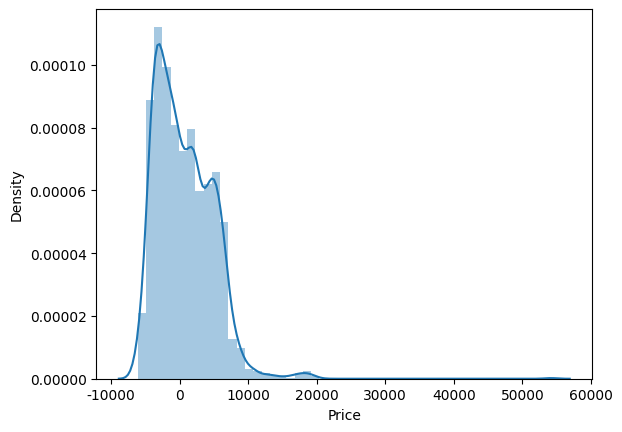

In [109]:
from sklearn.svm import SVR
predict(SVR())

Model is: GradientBoostingRegressor()
Training score: 0.8004872305794601
Predictions are: [ 5702.86974497 17826.76035345 12133.74946613 ...  4547.37535805
  6959.32889786 11428.58468176]


r2 score is: 0.8168061188758857
MAE:1397.4505612819867
MSE:3527522.3048542095
RMSE:1878.1699350309625


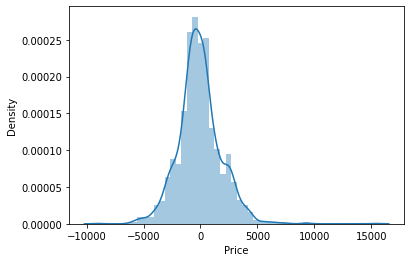

In [87]:
predict(GradientBoostingRegressor())

# Hypertunning the model

模型超参数调优

In [110]:
from sklearn.model_selection import RandomizedSearchCV
# 从 `sklearn.model_selection` 模块导入 `RandomizedSearchCV` 类，这是一个用于超参数优化的工具。
# `RandomizedSearchCV` 是一种通过随机采样超参数空间来寻找最佳超参数的技术，通常比网格搜索（GridSearchCV）更加高效。

In [111]:
random_grid = {
    'n_estimators' : [100, 120, 150, 180, 200, 220],
    # 'n_estimators'：设置模型中的树的数量。这里的值是一个列表，表示可能的树的数量（从 100 到 220），
    # 用于指定集成学习模型（如随机森林或梯度提升树）中学习器（树）的数量。树的数量越多，模型的复杂度越高。

    'max_features':['auto','sqrt'],
    # 'max_features'：用于设置每个树在分裂节点时考虑的特征数量。
    # 'auto' 表示每个树都考虑所有特征；'sqrt' 表示每个树只考虑特征数的平方根。
    # 选择不同的值可以控制模型的复杂度，从而影响性能和计算时间。

    'max_depth':[5, 10, 15, 20],
    # 'max_depth'：设置每棵树的最大深度。限制树的深度有助于控制过拟合。 
    # 这里的值表示可能的树深度，从 5 到 20，树深度越大，模型的表达能力越强，但可能导致过拟合。
}

In [112]:
rf = RandomForestRegressor()
# 创建一个 `RandomForestRegressor` 对象 `rf`，它是一个随机森林回归模型。
# 随机森林回归是集成学习方法的一种，通过构建多个决策树来进行回归预测。
# 它具有较强的鲁棒性，并能有效处理复杂的数据。

rf_random = RandomizedSearchCV(estimator=rf, param_distributions=random_grid, cv=3, verbose=2, n_jobs=-1)
# 创建一个 `RandomizedSearchCV` 对象 `rf_random`，用于通过随机搜索来调优 `RandomForestRegressor` 模型的超参数。
# 参数解释：
# - `estimator=rf`：指定要调优的模型是 `RandomForestRegressor`。
# - `param_distributions=random_grid`：指定要搜索的超参数空间，这里用 `random_grid` 定义了多个超参数的候选值。
# - `cv=3`：指定交叉验证的折数为 3，即每次训练时将数据分为 3 份进行交叉验证。
# - `verbose=2`：控制日志输出的详细程度，值越大，输出的信息越详细。`verbose=2` 会输出每个搜索步骤的信息。
# - `n_jobs=-1`：表示使用所有可用的 CPU 核心来加速计算。

rf_random.fit(X_train, y_train)
# 使用训练集 `X_train` 和 `y_train` 训练 `RandomizedSearchCV` 对象。
# `fit` 方法会通过在指定的超参数空间中进行随机搜索，找到最优的超参数组合并训练模型。

# best parameter
rf_random.best_params_
# 输出在随机搜索过程中找到的最佳超参数组合。
# `best_params_` 返回一个字典，包含找到的最佳参数（例如树的数量、最大深度等），用于提高模型的性能。


Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'n_estimators': 180, 'max_features': 'sqrt', 'max_depth': 15}

In [113]:
# best parameter
rf_random.best_params_

{'n_estimators': 180, 'max_features': 'sqrt', 'max_depth': 15}

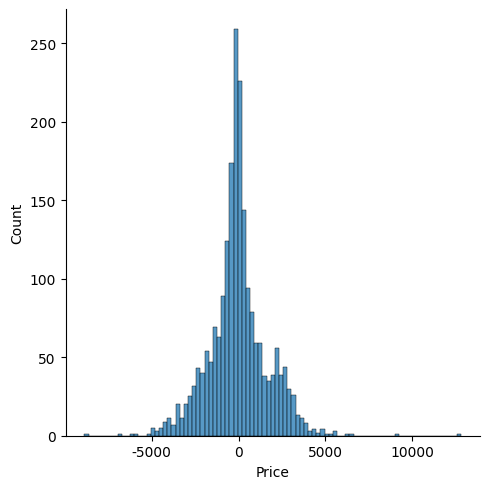

In [114]:
#predicting the values
prediction = rf_random.predict(X_test)

#distribution plot between actual value and predicted value
sns.displot(y_test-prediction)

In [115]:
r2_score(y_test,prediction)

0.8533616960704804

## After hypertuning,the accuracy increases .


#### IF YOU LIKE THE WORK,PLEASE UPVOTE IT.
5.1 经过超参数调优后，准确率提高了。  

5.1.0.1 如果你喜欢这项工作，请点赞支持。

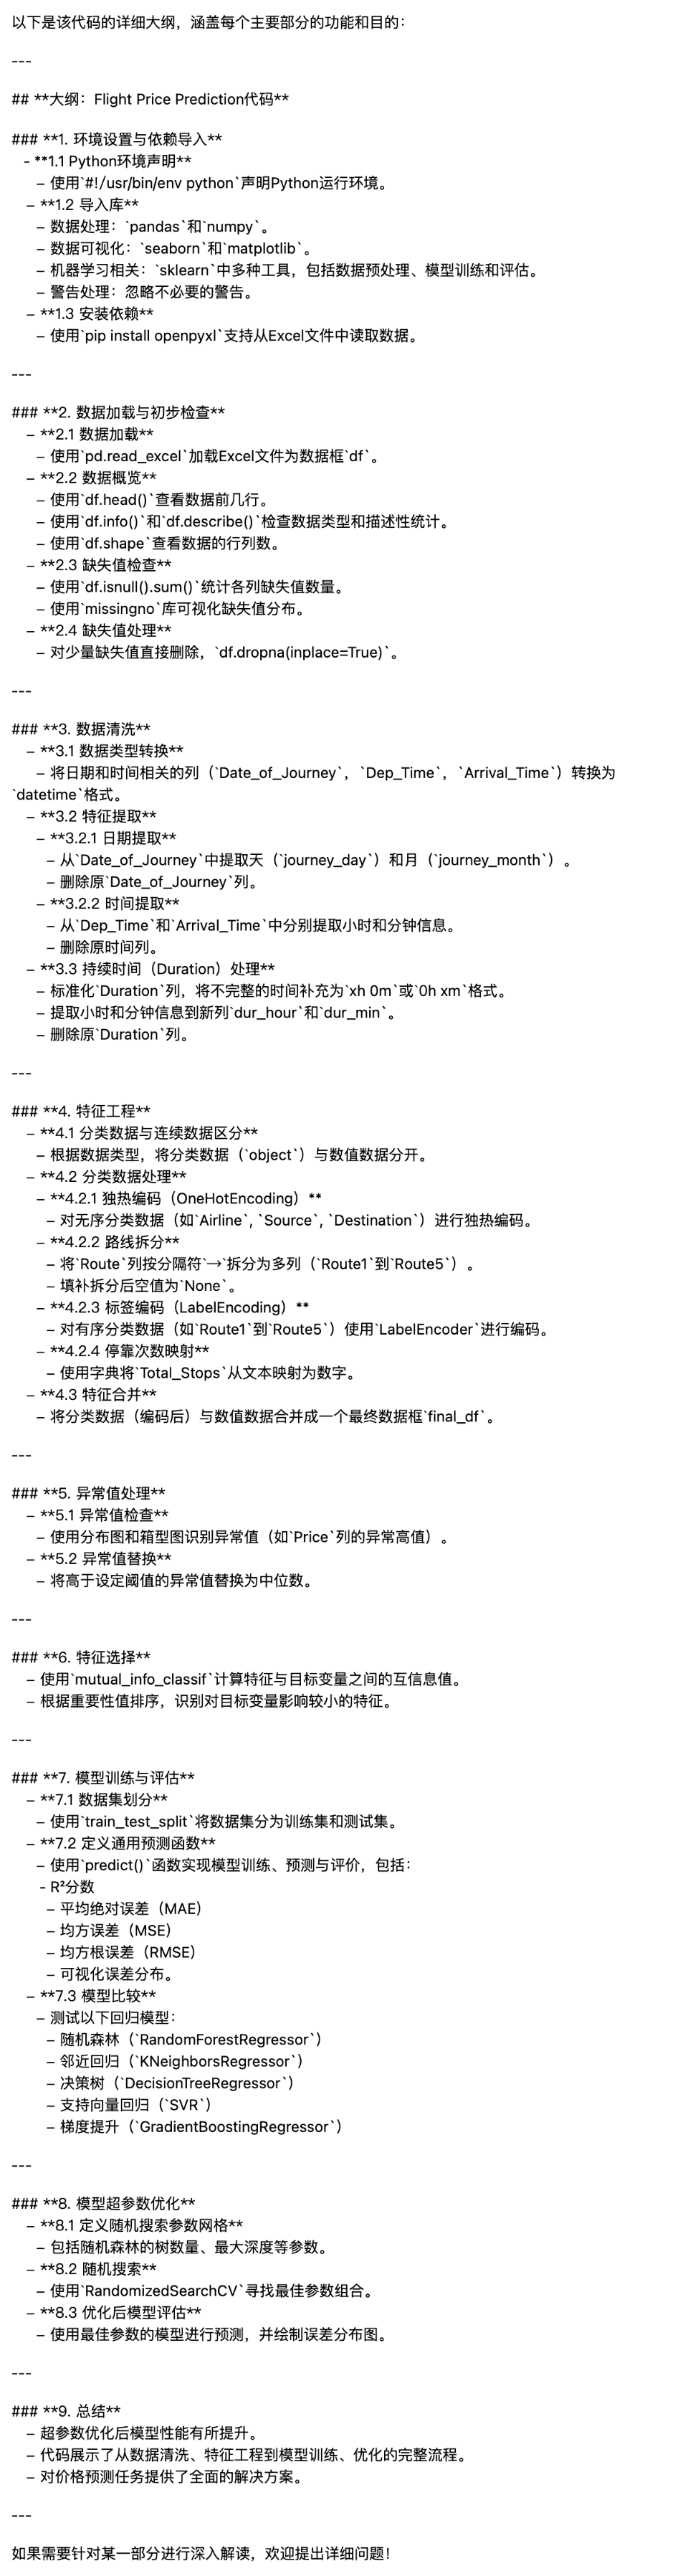